# 06 · Spatial Rainfall Analysis

Visualises the cumulative rainfall field (mm) for each WRF storm event,
comparing the **Historical** (noPGW) and **Future** (PGW) scenarios side-by-side.

Data source: HDF5-format `.mat` files on the hydrolab server.
- Historical: `WRFrain_noPGW_HPE{nn}.mat` — contains variables `lat`, `lon`, `rainRate`, `totalRain`
- Future:     `WRFrain_PGW_V3_HPE{nn}.mat` — contains variables `lat`, `lon`, `rainRatePGW`, `totalRain`

Both file types include a pre-computed `totalRain` [mm] grid that is used directly.
If `totalRain` is absent (edge case), the function falls back to integrating the
rain-rate variable over time using the `timesList` MATLAB datenum vector.

In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pathlib import Path

plt.rcParams['figure.dpi'] = 150

In [15]:
# ── Read-only data sources ────────────────────────────────────────────────────
HIST_DIR = Path(r"\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\matfiles\historical")
FUT_DIR  = Path(r"\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\matfiles\future")

HIST_FNAME = "WRFrain_noPGW_HPE{nn:02d}.mat"
FUT_FNAME  = "WRFrain_PGW_V3_HPE{nn:02d}.mat"

# Watershed boundary shapefile (READ-ONLY)
WATERSHED_SHP = Path(r"D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp")

# ── Event selection ───────────────────────────────────────────────────────────
# Full event list (HPE 01–41). Adjust PLOT_EVENTS to a subset for quick inspection.
ALL_EVENTS  = list(range(1, 42))
PLOT_EVENTS = list(range(1, 42))   # change to e.g. [1, 4, 10] for a subset

# ── Output directory ──────────────────────────────────────────────────────────
FIG_DIR = Path(r"D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\figures\spatial_rainfall")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Historical directory accessible : {HIST_DIR.exists()}")
print(f"Future directory accessible     : {FUT_DIR.exists()}")
print(f"Watershed shapefile accessible  : {WATERSHED_SHP.exists()}")
print(f"Output directory                : {FIG_DIR}")

Historical directory accessible : True
Future directory accessible     : True
Watershed shapefile accessible  : True
Output directory                : D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\figures\spatial_rainfall


In [16]:
def _reshape_wrf_grid(flat_array, side):
    """Reshape a flat WRF grid vector to a 2D (side x side) array.

    MATLAB stores 2D arrays in column-major (Fortran) order.  When a 550x550
    grid is flattened with MATLAB's A(:) operator, the resulting vector scans
    column-by-column.  Reshaping that vector in Python (row-major, C order)
    therefore produces the transpose of the original grid.  Applying .T after
    the reshape recovers the correct (lat x lon) orientation expected by
    pcolormesh(lon_2d, lat_2d, data_2d).

    Equivalent to: flat_array.reshape(side, side, order='F')
    """
    return flat_array.reshape(side, side).T


def load_cumulative_rain(mat_path, rate_key):
    """Load the cumulative rainfall grid [mm] from a WRF HDF5 .mat file.

    The coordinate and data arrays are stored as flat 1D vectors of length
    side*side (e.g. 302,500 = 550x550).  This function reshapes them back to
    2D before returning so that pcolormesh receives (lon_2d, lat_2d, rain_2d)
    arrays of matching shape rather than 1D vectors that would trigger an
    attempted 302,500 x 302,500 Cartesian grid allocation.

    Parameters
    ----------
    mat_path : Path or str
        Path to the HDF5-format .mat file.
    rate_key : str
        HDF5 key for the rain-rate variable: 'rainRate' (historical) or
        'rainRatePGW' (future).  Used only when 'totalRain' is absent.

    Returns
    -------
    lat     : np.ndarray, shape (side, side)  — latitude at each grid node
    lon     : np.ndarray, shape (side, side)  — longitude at each grid node
    rain_mm : np.ndarray, shape (side, side)  — cumulative rainfall [mm]
    """
    with h5py.File(str(mat_path), 'r') as f:
        lat_raw = np.array(f['lat']).flatten()
        lon_raw = np.array(f['lon']).flatten()

        if 'totalRain' in f:
            # Pre-computed cumulative total already in mm
            rain_raw = np.array(f['totalRain']).flatten()
        else:
            # Integrate rain rate [mm/hr] over all timesteps.
            # timesList is a MATLAB datenum vector; the difference between
            # consecutive entries (in days) x 24 gives the timestep in hours.
            times    = np.array(f['timesList']).flatten()
            dt_h     = float(times[1] - times[0]) * 24.0
            # Sum over the time axis (axis 0 after h5py transposition), then flatten
            rain_raw = np.array(f[rate_key]).sum(axis=0).flatten() * dt_h

    # All three raw arrays are 1D flat vectors representing a square 2D grid.
    # Reshape to 2D and transpose to undo MATLAB's column-major flattening order.
    n    = lat_raw.size
    side = int(np.sqrt(n))
    if side * side != n:
        raise ValueError(
            f"{mat_path}: grid size {n} is not a perfect square — "
            "cannot infer 2D shape automatically."
        )

    lat     = _reshape_wrf_grid(lat_raw,  side)
    lon     = _reshape_wrf_grid(lon_raw,  side)
    rain_mm = _reshape_wrf_grid(rain_raw, side)

    return lat, lon, rain_mm


def load_watershed(shp_path):
    """Return the watershed polygon dissolved to a single geometry in WGS-84."""
    return gpd.read_file(str(shp_path)).to_crs(epsg=4326).dissolve()


print("Helper functions defined.")

Helper functions defined.


In [17]:
# Geographic buffer constants for the watershed zoom window.
# Approximate conversions at Israel's latitude (~32 N):
#   1 degree latitude  ≈ 111 km  →  50 km N/S ≈ 0.45 degrees
#   1 degree longitude ≈  95 km  →  30 km E/W ≈ 0.32 degrees
_LAT_BUF_DEG = 0.45
_LON_BUF_DEG = 0.32


def plot_hist_future_comparison(
    event_num,
    hist_dir,
    fut_dir,
    watershed=None,
    cmap="YlGnBu",
    save_path=None,
):
    """Create a 1x2 side-by-side comparison of cumulative rainfall for one event.

    Both panels share the same colour scale (vmin=0, vmax=global_max) and a
    single shared colorbar.  When a watershed GeoDataFrame is supplied the map
    is zoomed to a window centred on the watershed bounding box with a buffer
    of +/-30 km E/W and +/-50 km N/S; otherwise the full WRF domain is shown.

    Parameters
    ----------
    event_num : int
        HPE event number (1-41).
    hist_dir : Path
        Directory containing historical .mat files.
    fut_dir : Path
        Directory containing future .mat files.
    watershed : GeoDataFrame or None
        Watershed boundary in WGS-84.  Overlaid on both panels and used to
        derive the zoomed map extent when provided.
    cmap : str
        Matplotlib colormap name.  Default 'YlGnBu' gives a yellow-green-blue
        perceptual ramp that clearly differentiates low, moderate, and extreme
        cumulative rainfall values.
    save_path : Path or None
        If given, the figure is saved here and closed.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    hist_path = hist_dir / HIST_FNAME.format(nn=event_num)
    fut_path  = fut_dir  / FUT_FNAME.format(nn=event_num)

    lat_h, lon_h, rain_h = load_cumulative_rain(hist_path, rate_key='rainRate')
    lat_f, lon_f, rain_f = load_cumulative_rain(fut_path,  rate_key='rainRatePGW')

    # Shared colour scale: 0 to global max across both grids
    vmax = float(max(rain_h.max(), rain_f.max()))

    # ── Map extent ────────────────────────────────────────────────────────────
    # Zoom to watershed bounding box + buffer when a watershed is available.
    # Falls back to the full WRF domain if no watershed is provided.
    if watershed is not None:
        minx, miny, maxx, maxy = watershed.total_bounds  # lon_min, lat_min, lon_max, lat_max
        map_extent = [
            minx - _LON_BUF_DEG,
            maxx + _LON_BUF_DEG,
            miny - _LAT_BUF_DEG,
            maxy + _LAT_BUF_DEG,
        ]
    else:
        margin = 0.2
        map_extent = [
            lon_h.min() - margin, lon_h.max() + margin,
            lat_h.min() - margin, lat_h.max() + margin,
        ]

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6),
        subplot_kw={'projection': proj},
    )
    fig.subplots_adjust(wspace=0.08, right=0.88)

    panels = [
        (axes[0], lat_h, lon_h, rain_h, "(a) Historical"),
        (axes[1], lat_f, lon_f, rain_f, "(b) Future (PGW)"),
    ]

    pcm = None
    for ax, lat, lon, rain, title in panels:
        # Land background drawn first so the rainfall grid renders on top of it
        ax.add_feature(cfeature.LAND.with_scale('10m'),
                       facecolor='#f5f5f0', zorder=0)

        # Rainfall grid at zorder=1; coastlines at zorder=3 ensures they are
        # drawn on top of the grid and remain clearly visible
        pcm = ax.pcolormesh(
            lon, lat, rain,
            cmap=cmap,
            vmin=0, vmax=vmax,
            transform=proj,
            zorder=1,
        )

        # Coastlines only — no political/country borders
        ax.add_feature(
            cfeature.COASTLINE.with_scale('10m'),
            linewidth=0.8,
            edgecolor='#222222',
            zorder=3,
        )

        if watershed is not None:
            watershed.plot(
                ax=ax,
                facecolor='none',
                edgecolor='red',
                linewidth=1.8,
                transform=proj,
                zorder=5,
            )

        ax.set_extent(map_extent, crs=proj)

        gl = ax.gridlines(
            draw_labels=True, linewidth=0.4,
            color='white', alpha=0.6, linestyle='--',
        )
        gl.top_labels   = False
        gl.right_labels = False
        gl.xformatter   = LONGITUDE_FORMATTER
        gl.yformatter   = LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 9}
        gl.ylabel_style = {'size': 9}
        gl.xlocator = mticker.MultipleLocator(0.5)
        gl.ylocator = mticker.MultipleLocator(0.5)

        ax.set_title(title, fontsize=13, fontweight='bold', pad=6)

    # Single shared colorbar positioned to the right of both panels
    cbar_ax = fig.add_axes([0.90, 0.12, 0.022, 0.74])
    cbar = fig.colorbar(pcm, cax=cbar_ax)
    cbar.set_label('Cumulative Rainfall (mm)', fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    fig.suptitle(
        f'HPE {event_num:02d} — Cumulative Rainfall: Historical vs. Future',
        fontsize=14, fontweight='bold', y=1.01,
    )

    if save_path is not None:
        fig.savefig(str(save_path), dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f'  Saved: {Path(save_path).name}')

    return fig


print("Plotting function defined.")

Plotting function defined.


In [18]:
# Load watershed boundary once (reused across all event plots)
watershed = load_watershed(WATERSHED_SHP) if WATERSHED_SHP.exists() else None
if watershed is not None:
    print(f"Watershed loaded: {len(watershed)} polygon(s)")
else:
    print("Watershed shapefile not found — overlay will be skipped.")

Watershed loaded: 1 polygon(s)


C:\Users\raznu\AppData\Local\Temp\ipykernel_30196\4271481394.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


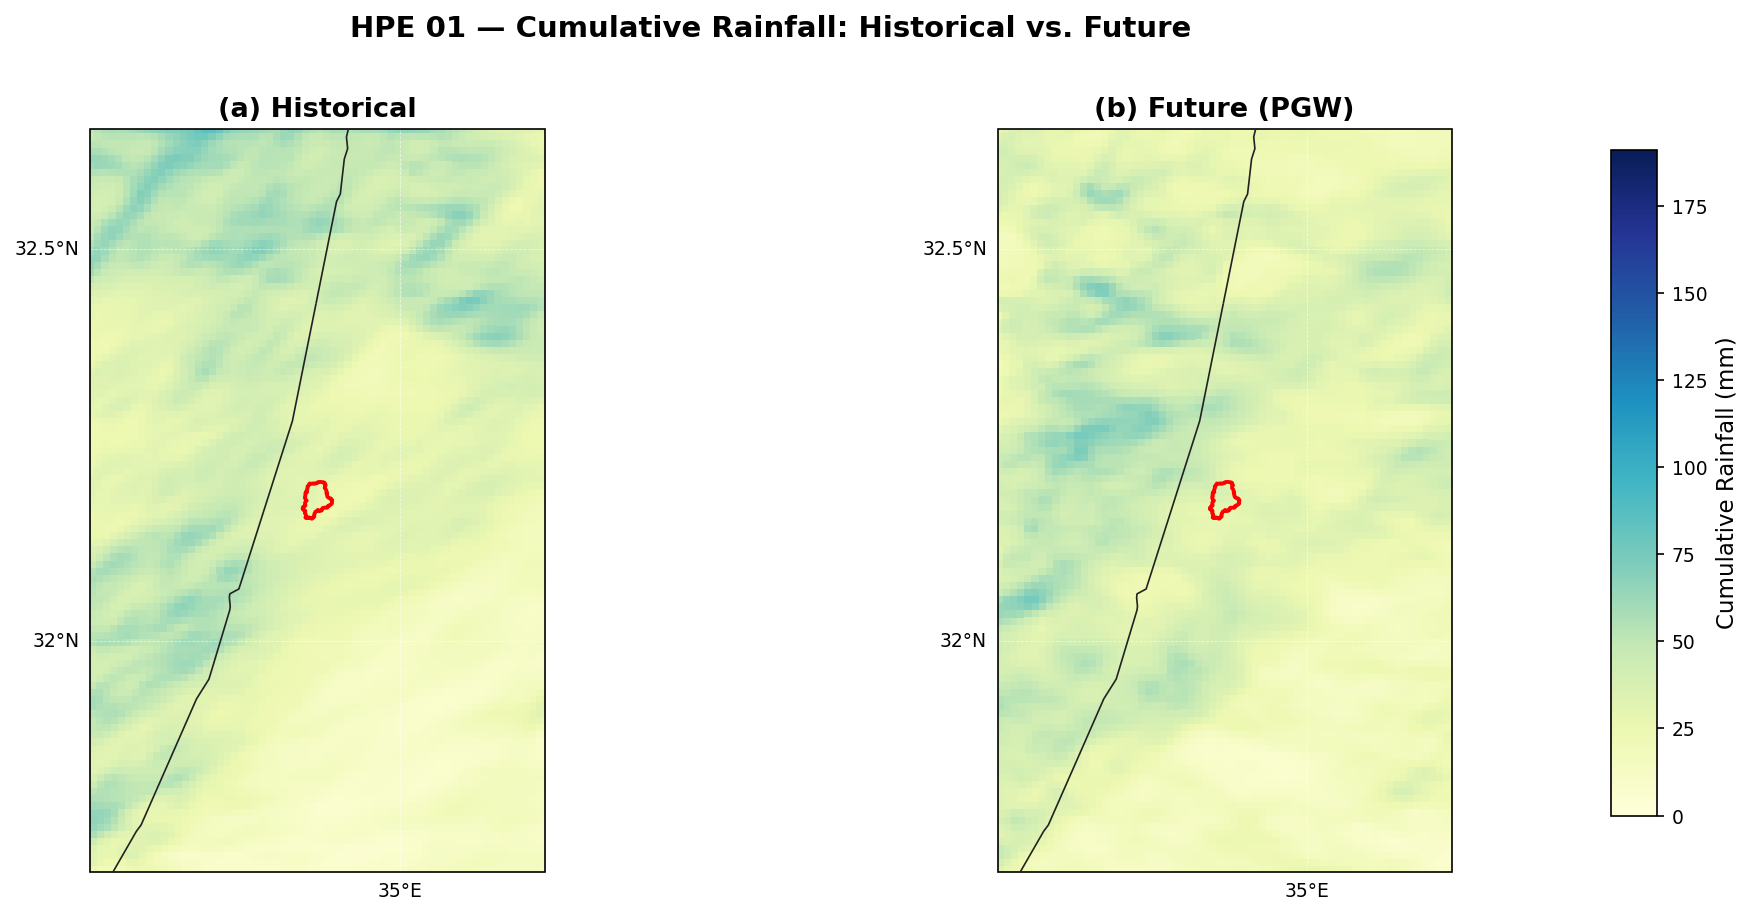

In [19]:
# ── Quick preview: plot a single event inline ─────────────────────────────────
PREVIEW_EVENT = 1

fig = plot_hist_future_comparison(
    event_num=PREVIEW_EVENT,
    hist_dir=HIST_DIR,
    fut_dir=FUT_DIR,
    watershed=watershed,
)
plt.tight_layout()
plt.show()

In [20]:
# ── Batch export: save all selected events as PNG images ─────────────────────
# PNG at dpi=150 gives ~2100x900 px per figure — high enough for publication
# review and easy to flip through in any image viewer.
print(f"Exporting {len(PLOT_EVENTS)} event figure(s) to {FIG_DIR} ...")

for ev in PLOT_EVENTS:
    out_path = FIG_DIR / f"spatial_rain_event_{ev:02d}.png"
    plot_hist_future_comparison(
        event_num=ev,
        hist_dir=HIST_DIR,
        fut_dir=FUT_DIR,
        watershed=watershed,
        save_path=out_path,
    )

print("Done.")

Exporting 41 event figure(s) to D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\figures\spatial_rainfall ...
  Saved: spatial_rain_event_01.png
  Saved: spatial_rain_event_02.png
  Saved: spatial_rain_event_03.png
  Saved: spatial_rain_event_04.png
  Saved: spatial_rain_event_05.png
  Saved: spatial_rain_event_06.png
  Saved: spatial_rain_event_07.png
  Saved: spatial_rain_event_08.png
  Saved: spatial_rain_event_09.png
  Saved: spatial_rain_event_10.png
  Saved: spatial_rain_event_11.png
  Saved: spatial_rain_event_12.png
  Saved: spatial_rain_event_13.png
  Saved: spatial_rain_event_14.png
  Saved: spatial_rain_event_15.png
  Saved: spatial_rain_event_16.png
  Saved: spatial_rain_event_17.png
  Saved: spatial_rain_event_18.png
  Saved: spatial_rain_event_19.png
  Saved: spatial_rain_event_20.png
  Saved: spatial_rain_event_21.png
  Saved: spatial_rain_event_22.png
  Saved: spatial_rain_event_23.png
  Saved: spatial_rain_event_24.png
  Saved: spatial_rain_event_25.png
  Saved: spat